In [1]:
from shapely.geometry import box
import folium
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.lines import Line2D
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.ticker import FuncFormatter


In [2]:
from src.myio import reader,  read_gpkg, read_csv, write_parquet, read_dem, read_parquet


In [4]:
basin_3857 = reader("basin_bil_cher_3857.parquet").read_parquet()
basin_4326 = reader("basin_bil_cher_4326.gpkg").read_gpkg()


In [5]:
print(basin_4326)
print(basin_3857)

   cat  value label                                           geometry
0    1      1        POLYGON ((24.99208 48.11903, 24.99208 48.11917...
   fid  cat  value label                                           geometry
0    1    1      1        POLYGON ((2782105.991 6126679.709, 2782105.991...


In [6]:
# 1. Об'єднуємо всі полігони у один (це весь басейн!)
basin_poly = basin_4326.geometry.union_all()
print(basin_poly.bounds)

(24.721527777777776, 47.69847222222222, 25.119027777777777, 48.12125)


In [7]:
# 2. Завантаження твого полігону
tracks = reader("geo_parqet_file/icesat2_night.parquet").read_parquet()
print(tracks)

                               sc_orient  region  segment_id  track  \
time                                                                  
2018-11-04 01:05:32.246215936          1       6      735621      1   
2018-11-04 01:05:32.246416128          1       6      735621      1   
2018-11-04 01:05:32.247016192          1       6      735621      1   
2018-11-04 01:05:32.247316224          1       6      735621      1   
2018-11-04 01:05:32.247916288          1       6      735621      1   
...                                  ...     ...         ...    ...   
2023-11-12 21:08:43.964583424          1       2      266316      1   
2023-11-12 21:08:43.964783104          1       2      266316      1   
2023-11-12 21:08:43.964783104          1       2      266316      1   
2023-11-12 21:08:43.964883200          1       2      266316      1   
2023-11-12 21:08:43.964983296          1       2      266316      1   

                               background_rate  solar_elevation  segment_dis

In [8]:
if tracks.crs != basin_4326.crs:
    # Приводимо GeoDataFrame до потрібної CRS
    basin = basin_4326.to_crs(tracks.crs)

In [9]:
tracks_in_basin = tracks[tracks.within(basin_poly)]

In [18]:
tracks_in_basin.to_parquet("icesat2_night_cut_4326.parquet")


In [19]:

# Переводимо в 3857
tracks_proj = tracks_in_basin.to_crs(epsg=3857)
tracks_proj.to_parquet("icesat2_night_cut_3857.parquet")



In [10]:
tracks_proj_32635 = tracks_in_basin.to_crs(epsg=32635)
tracks_proj.to_parquet("icesat2_night_cut_32635.parquet")

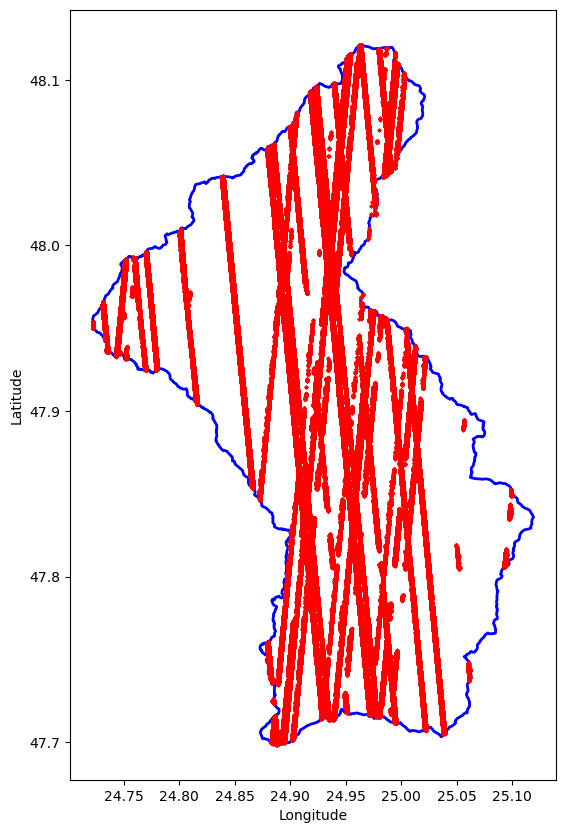

In [22]:

fig, ax = plt.subplots(figsize=(10, 10))

# Намалюй полігон басейну
basin_4326.plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=2)

# Намалюй точки у басейні
tracks_in_basin.plot(ax=ax, color='red', markersize=2, alpha=0.7)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [16]:
print(tracks_in_basin.crs)
print(basin_poly)

EPSG:3857
POLYGON ((24.889756358280422 47.69448092515877, 24.889339691613753 47.69434203626988, 24.8884748229723 47.69414586066589, 24.887363711861187 47.69400697177701, 24.88624739924992 47.69400697177701, 24.88513628813881 47.69414586066589, 24.88417381840775 47.69437581933172, 24.883683338787407 47.69461570497104, 24.883010204557113 47.694727894009425, 24.882326975052965 47.69489759182543, 24.881493641719633 47.6951753696032, 24.88055087666215 47.69561651580684, 24.880423620798048 47.69571722842892, 24.880382530608458 47.695730925158784, 24.879439765551034 47.69617207136241, 24.87862357504026 47.696818019484624, 24.878484686151328 47.69695690837355, 24.878345797262398 47.69709579726248, 24.878287622099972 47.69715397242491, 24.87805323519028 47.69732290895113, 24.87791406591656 47.697340305110345, 24.87680295480545 47.697479193999236, 24.875938086164012 47.697675369603225, 24.87593582427596 47.697676123565905, 24.875138888888905 47.697583333333334, 24.874105000746468 47.697703712880

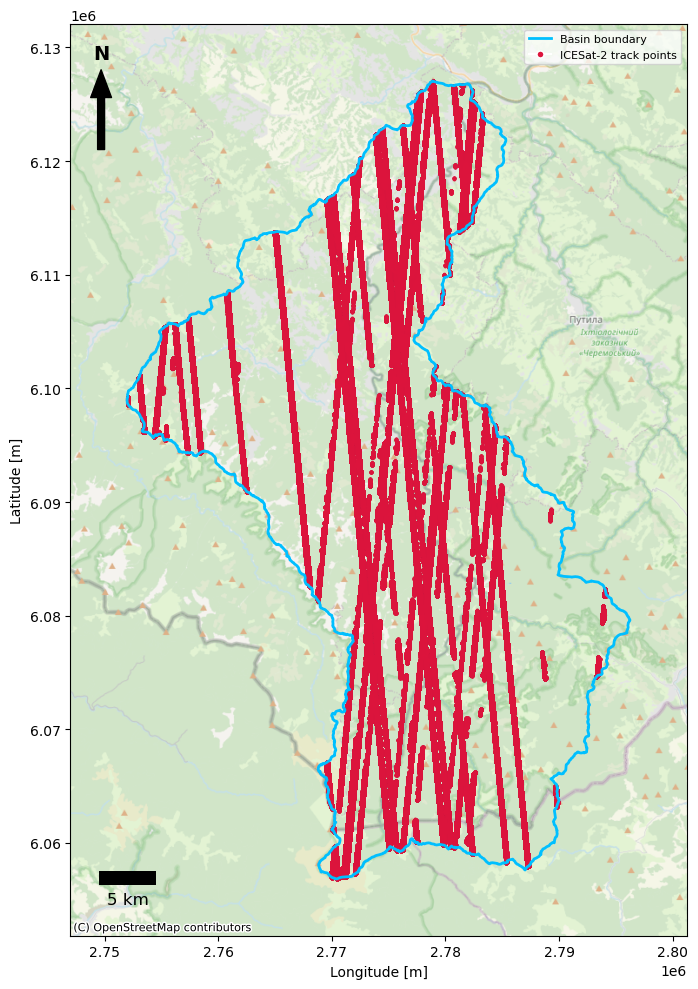

In [36]:

# --- Підготовка даних ---


# 2. Визначаємо межі для мапи (і трошки розширюємо, щоб не було "обрізки")
xmin, ymin, xmax, ymax = basin_3857.total_bounds
pad = 5000  # 5 км буфер
axlim = (xmin - pad, xmax + pad, ymin - pad, ymax + pad)

# --- Малювання ---
fig, ax = plt.subplots(figsize=(10, 10))

# Полігон (басейн)
basin_3857.boundary.plot(ax=ax, edgecolor='deepskyblue', linewidth=2, label='Basin boundary')
# Траєкторії
tracks_proj.plot(ax=ax, color='crimson', markersize=3, alpha=0.7, label="ICESat-2 track points")

# Базова карта
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, crs=3857, alpha=0.7)

# Коректуємо межі
ax.set_xlim(axlim[0], axlim[1])
ax.set_ylim(axlim[2], axlim[3])
# 5. Масштабна лінійка — автоматична, прозорий фон, підпис великий
scalebar = ScaleBar(
    dx=1, units='m', length_fraction=0.1, location='lower left',
    width_fraction=0.015, box_alpha=0, color='black', scale_loc='bottom',
    font_properties={'size': 12}, pad=2.0
)
ax.add_artist(scalebar)
# Підписи
ax.set_xlabel("Longitude [m]")
ax.set_ylabel("Latitude [m]")
ax.set_title("ICESat-2 ground tracks within the study basin", fontsize=14, pad=12)

# Легенда
legend_elements = [
    Line2D([0], [0], color='deepskyblue', lw=2, label='Basin boundary'),
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()


In [35]:
print(ctx.providers)

{'OpenStreetMap': {'Mapnik': {'url': 'https://tile.openstreetmap.org/{z}/{x}/{y}.png', 'max_zoom': 19, 'html_attribution': '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors', 'attribution': '(C) OpenStreetMap contributors', 'name': 'OpenStreetMap.Mapnik'}, 'DE': {'url': 'https://tile.openstreetmap.de/{z}/{x}/{y}.png', 'max_zoom': 18, 'html_attribution': '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors', 'attribution': '(C) OpenStreetMap contributors', 'name': 'OpenStreetMap.DE'}, 'CH': {'url': 'https://tile.osm.ch/switzerland/{z}/{x}/{y}.png', 'max_zoom': 18, 'html_attribution': '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors', 'attribution': '(C) OpenStreetMap contributors', 'bounds': [[45, 5], [48, 11]], 'name': 'OpenStreetMap.CH'}, 'France': {'url': 'https://{s}.tile.openstreetmap.fr/osmfr/{z}/{x}/{y}.png', 'max_zoom': 20, 'html_attribution': '&copy; OpenStreetMap 

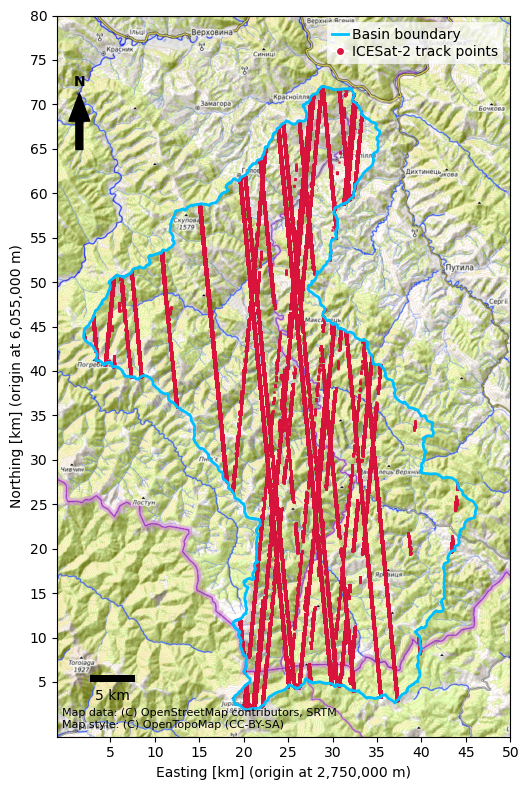

In [75]:


# --- Функція для додавання стрілки North ---
def add_north_arrow(ax, size, pad=0.05, color='black'):
    """Додає стрілку 'N' у верхній лівий кут."""
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    x = xlim[0] + (xlim[1] - xlim[0]) * pad
    y = ylim[1] - (ylim[1] - ylim[0]) * pad
    ax.annotate('', xy=(x, y), xytext=(x, y - size),
                arrowprops=dict(facecolor=color, width=5, headwidth=15, headlength=20),
                annotation_clip=False)
    ax.text(x, y + size * 0.08, 'N', color=color, fontsize=10, fontweight='bold',
            ha='center', va='bottom')

# --- Малювання карти ---
fig, ax = plt.subplots(figsize=(8, 8))

# 1. Полігон басейну
basin_3857.boundary.plot(ax=ax, edgecolor='deepskyblue', linewidth=2)
# 2. Траєкторії ICESat-2
tracks_proj.plot(ax=ax, color='crimson', markersize=1.0, alpha=0.1)

# 3. Додаємо підкладку-карту
ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap, attribution=False, crs=3857)

# 4. Межі області + буфер
xmin, ymin, xmax, ymax = basin_3857.total_bounds
pad = 3000
ax.set_xlim(xmin - pad, xmax + pad)
ax.set_ylim(ymin - pad, ymax + pad)

# 5. Масштабна лінійка — автоматична, прозорий фон, підпис великий
scalebar = ScaleBar(
    dx=1, units='m', length_fraction=0.1, location='lower left',
    width_fraction=0.010, box_alpha=0, color='black', scale_loc='bottom',
    font_properties={'size': 10}, pad=2.3
)
ax.add_artist(scalebar)

# 6. Стрілка North (завжди однаково)
size_arrow = (ymax - ymin) * 0.09
add_north_arrow(ax, size=size_arrow)

# 7. Легенда — компактна
legend_elems = [
    Line2D([0], [0], color='deepskyblue', lw=2, label='Basin boundary'),
    Line2D([0], [0], marker='o', color='w', label='ICESat‑2 track points',
           markerfacecolor='crimson', markersize=6)
]
leg = ax.legend(
    handles=legend_elems,
    loc='upper right',
    fontsize=10,
    handlelength=1.1,
    handletextpad=0.3,
    borderaxespad=0.5,
    labelspacing=0.2,
    frameon=True
)
leg.get_frame().set_alpha(0.75)      # повністю прозорий фон
leg.get_frame().set_linewidth(0.2)  # без рамки

from matplotlib.ticker import MultipleLocator, FuncFormatter

# Set 5 km ticks (5000 m)
step_km = 5
step_m = step_km * 1000

x0 = int((xmin - pad*0.5) // 1000) * 1000
y0 = int((ymin - pad*0.5) // 1000) * 1000

ax.xaxis.set_major_locator(MultipleLocator(step_m))
ax.yaxis.set_major_locator(MultipleLocator(step_m))

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int((x-x0)/1000):d}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int((y-y0)/1000):d}'))

ax.set_xlabel(f"Easting [km] (origin at {x0:,} m)", fontsize=10)
ax.set_ylabel(f"Northing [km] (origin at {y0:,} m)", fontsize=10)


# # Now get ticks and filter out zero
ticks_x = ax.get_xticks()
ticks_y = ax.get_yticks()
ax.set_xticks([tick for tick in ticks_x if int((tick-x0)/1000) > 0])
ax.set_yticks([tick for tick in ticks_y if int((tick-y0)/1000) > 0])
ax.text(
    0.01, 0.01,
    'Map data: (C) OpenStreetMap contributors, SRTM\nMap style: (C) OpenTopoMap (CC-BY-SA)',
    fontsize=8, color='black',
    transform=ax.transAxes,
    ha='left', va='bottom',
    bbox=dict(facecolor='white', alpha=0.1, edgecolor='none', pad=0.05)
)


plt.tight_layout()
plt.savefig("ICESat‑2_track_OpenTopoMap.png", dpi=600, bbox_inches='tight')

plt.show()
